In [4]:
using Revise

In [5]:
using GeneRegulatorySystems
using GeneRegulatorySystems.Models
using GeneRegulatorySystems.Models.NetworkRepresentation
using GeneRegulatorySystems.Models.V1
using GeneRegulatorySystems.Scheduling
import JSON
using GarishPrint

macro pp(x) :(GarishPrint.pprint($(esc(x)))) end;

In [12]:

# Load ACDC (has proteolysis) and inspect current heuristic behaviour
using Catalyst

schedule_acdc = Models.load("examples/toy/ACDC.schedule.json", seed="seed123")

model_path = nothing
schedule_acdc(Models.FlatState(); dryrun = (primitive!, x, dt; path, _...) -> begin
    if isfinite(dt) && dt > 0.0 && model_path === nothing
        global model_path = primitive!.path
    end
end)
println("Model path: $model_path")

wrapped = Scheduling.reify(schedule_acdc, model_path)
v1_def_loaded = wrapped.model.definition
rs_loaded = wrapped.model.model.definition

all_rxns_acdc_loaded = Catalyst.reactions(rs_loaded)
reg_filtered = [rxn for rxn in all_rxns_acdc_loaded if NetworkRepresentation._is_regulation_reaction(rxn)]
non_reg      = [rxn for rxn in all_rxns_acdc_loaded if !NetworkRepresentation._is_regulation_reaction(rxn)]

println("Total reactions:       $(length(all_rxns_acdc_loaded))")
println("Heuristic-filtered:    $(length(reg_filtered))")
println("Surviving (heuristic): $(length(non_reg))")

println("\n=== Heuristic-filtered reactions ===")
for rxn in reg_filtered
    id = NetworkRepresentation._reaction_id(rxn)
    subs = isempty(rxn.substrates) ? "(none)" : join([String(NetworkRepresentation.SpeciesId(s).name) for s in rxn.substrates], " + ")
    prods = isempty(rxn.products) ? "(none)" : join([String(NetworkRepresentation.SpeciesId(p).name) for p in rxn.products], " + ")
    println("  $subs -> $prods  [id=$id]")
end


Model path: -2-1/1.do
Total reactions:       30
Heuristic-filtered:    6
Surviving (heuristic): 24

=== Heuristic-filtered reactions ===
  1.active -> (none)  [id=[1]1.active->]
  (none) -> 1.active  [id=->[1]1.active]
  2.active -> (none)  [id=[1]2.active->]
  (none) -> 2.active  [id=->[1]2.active]
  3.active -> (none)  [id=[1]3.active->]
  (none) -> 3.active  [id=->[1]3.active]


Load schedule

In [3]:
path_diff = "examples/specification/differentiation.schedule.json"
path_v1 = "examples/toy/ACDC.schedule.json"
path_kronecker = "examples/benchmark/kronecker-small.schedule.json"
path_rand_diff = "examples/specification/random-differentiation.schedule.json"

schedule! = Models.load(path_v1, seed="seed123");

In [ ]:

# Dryrun ACDC: inspect what segments are generated and their execution paths
sched_acdc = Models.load("examples/toy/ACDC.schedule.json", seed="seed123")

segments = []
sched_acdc(Models.FlatState(); dryrun = (primitive!, x, Δt; path, _...) -> begin
    push!(segments, (
        execution_path = path,
        model_path = primitive!.path,
        from = x.t,
        to = x.t + (isfinite(Δt) ? Δt : 0.0),
        is_instant = !isfinite(Δt) || Δt == 0.0,
    ))
end)

println("Total segments: $(length(segments))\n")
println("$(rpad("execution_path", 30))  $(rpad("model_path", 40))  from -> to")
println("-"^90)
for s in segments
    println("$(rpad(s.execution_path, 30))  $(rpad(s.model_path, 40))  $(s.from) -> $(s.to)$(s.is_instant ? "  [instant]" : "")")
end


In [ ]:
f! = Scheduling.reify(schedule!, "-2-1+-1+")

In [ ]:
rs = f!.f!.model.model.definition

Reify the schedule. Need to do a dryrun to get all the primitives

In [ ]:
# this only extracts the first network that it finds in the schedule, rather than all of them
function extract_network(schedule::Scheduling.Schedule)
    network = nothing
    
    function dryrun_collector(primitive!, x, Δt; path, _...)
        if !(isfinite(Δt) && Δt > 0.0)
            return
        end
        if network === nothing
            network = Models.NetworkRepresentation.entity(primitive!)
        end
    end
    
    schedule(Models.FlatState(); dryrun=dryrun_collector)
    return network
end

network = extract_network(schedule!)

# Reaction filtering exploration

Goal: find a principled way to identify which Catalyst reactions are "implementation artifacts" of explicit regulatory links (activation, repression, proteolysis) in a V1 definition, so we can filter exactly those rather than using a heuristic on species names.

Plan:
1. Load `copies.schedule.json` (has explicit `inactive` species + activation links)
2. Inspect both the V1 regulatory links AND the Catalyst reactions side by side
3. Understand what reactions V1 generates per link type
4. Derive a principled ID-based filter

In [7]:

# Load copies.schedule.json — has explicit inactive species + activation links
using Catalyst

sched_copies = Models.load("examples/specification/copies.schedule.json", seed="seed123")

wrapped_copies = nothing
sched_copies(Models.FlatState(); dryrun = (primitive!, x, dt; path, _...) -> begin
    if isfinite(dt) && dt > 0.0 && wrapped_copies === nothing
        global wrapped_copies = Scheduling.reify(sched_copies, primitive!.path)
    end
end)

v1_def = wrapped_copies.model.definition
rs = wrapped_copies.model.model.definition

println("Genes: ", [g.name for g in v1_def.genes])
println()

# Show all V1 regulatory links
desc = Models.describe(v1_def)
components = Dict(typeof(d) => d for d in desc.descriptions)
raw_links = components[Models.Network].links
println("=== Regulatory links in V1 definition ===")
for lnk in raw_links
    println("  kind=$(lnk.kind)  from=$(lnk.from)  to=$(lnk.to)  props=$(lnk.properties)")
end


Genes: [Symbol("1")]

=== Regulatory links in V1 definition ===


In [8]:
# List ALL Catalyst reactions with their IDs to understand what V1 generates
all_rxns = Catalyst.reactions(rs)
println("=== All $(length(all_rxns)) Catalyst reactions ===")
for rxn in all_rxns
    subs = [String(NetworkRepresentation.SpeciesId(s).name) for s in rxn.substrates]
    prods = [String(NetworkRepresentation.SpeciesId(p).name) for p in rxn.products]
    rxn_id = NetworkRepresentation._reaction_id(rxn)
    filtered = NetworkRepresentation._is_regulation_reaction(rxn)
    marker = filtered ? " [FILTERED]" : ""
    println("  $(join(subs, " + ")) -> $(join(prods, " + "))$marker")
end

=== All 10 Catalyst reactions ===
  1.active -> 1.inactive [FILTERED]
  1.inactive -> 1.active [FILTERED]
  1.active + polymerases -> 1.active + 1.elongations
  1.elongations -> 1.premrnas + polymerases
  1.premrnas -> 1.mrnas
  1.mrnas + ribosomes -> 1.mrnas + 1.proteins + ribosomes
  1.elongations -> polymerases
  1.premrnas -> 
  1.mrnas -> 
  1.proteins + proteasomes -> proteasomes


In [9]:
# Principled approach: derive the Catalyst reaction IDs that V1 generates
# per regulatory link type, from reading the V1 source.
#
# ACTIVATION(from=A, to=B):
#   basal deactivation:  B.active → B.inactive   (or B.active → 0 if B.unique)
#   basal activation:    B.inactive → B.active    (or 0 → B.active if B.unique)
#
# REPRESSION(from=A, to=B): same basal pair as activation (same reactions, different rates)
#   The catalytic effect is encoded in the *rate* expression, not the reaction stoichiometry.
#   So activation and repression share identical stoichiometric reactions!
#
# PROTEOLYSIS(from=A, to=B):
#   normal:    A.proteins + B.proteins → A.proteins
#   self-loop: B.proteins → 0  (stoich [2]→[1], net: one copy removed)
#
# Key insight: activation and repression basal reactions have the same IDs
# regardless of which gene does the regulating. We need per-target IDs only.
# The regulator (from) does NOT appear in the stoichiometry of these reactions.

gene_lookup = Dict(g.name => g for g in v1_def.genes)

function regulatory_reaction_ids_v2(raw_links, gene_lookup)::Set{Symbol}
    ids = Set{Symbol}()
    targets_seen = Set{Symbol}()  # avoid duplicates (activation + repression hit same basal rxns)

    for lnk in raw_links
        to = lnk.to
        from = lnk.from

        if lnk.kind in (:activation, :repression)
            target_gene = get(gene_lookup, to, nothing)
            to in targets_seen && continue
            push!(targets_seen, to)
            if target_gene !== nothing && target_gene.unique
                # unique gene: no inactive species, products/substrates are nothing
                push!(ids, Symbol("[1]$(to).active->"))        # B.active → 0
                push!(ids, Symbol("->[1]$(to).active"))        # 0 → B.active
            else
                push!(ids, Symbol("[1]$(to).active->[1]$(to).inactive"))
                push!(ids, Symbol("[1]$(to).inactive->[1]$(to).active"))
            end

        elseif lnk.kind == :proteolysis
            if from == to
                # self-loop: B.proteins → 0 (stoich [2]→[1])
                push!(ids, Symbol("[2]$(to).proteins->[1]$(to).proteins"))
            else
                push!(ids, Symbol("[1]$(from).proteins;[1]$(to).proteins->[1]$(from).proteins"))
            end
        end
    end
    ids
end

gene_names = Set{Symbol}(g.name for g in v1_def.genes)
principled_ids_v2 = regulatory_reaction_ids_v2(raw_links, gene_lookup)

println("=== Principled filter v2: $(length(principled_ids_v2)) IDs ===")
for id in principled_ids_v2
    println("  $id")
end

println()
println("=== Reactions matched ===")
for rxn in all_rxns
    rxn_id = NetworkRepresentation._reaction_id(rxn)
    subs = [String(NetworkRepresentation.SpeciesId(s).name) for s in rxn.substrates]
    prods = [String(NetworkRepresentation.SpeciesId(p).name) for p in rxn.products]
    matched = rxn_id in principled_ids_v2
    println("  $(join(subs, " + ")) -> $(join(prods, " + "))  [$(matched ? "FILTERED" : "kept")]")
end

=== Principled filter v2: 0 IDs ===

=== Reactions matched ===
  1.active -> 1.inactive  [kept]
  1.inactive -> 1.active  [kept]
  1.active + polymerases -> 1.active + 1.elongations  [kept]
  1.elongations -> 1.premrnas + polymerases  [kept]
  1.premrnas -> 1.mrnas  [kept]
  1.mrnas + ribosomes -> 1.mrnas + 1.proteins + ribosomes  [kept]
  1.elongations -> polymerases  [kept]
  1.premrnas ->   [kept]
  1.mrnas ->   [kept]
  1.proteins + proteasomes -> proteasomes  [kept]


In [10]:
# Diagnostic: print exact _reaction_id output for ALL reactions in copies model
# so we can verify the ID format matches what we generate above
println("=== Exact reaction IDs in copies model ===")
for rxn in all_rxns
    id = NetworkRepresentation._reaction_id(rxn)
    subs = isempty(rxn.substrates) ? ["(none)"] : [String(NetworkRepresentation.SpeciesId(s).name) for s in rxn.substrates]
    prods = isempty(rxn.products) ? ["(none)"] : [String(NetworkRepresentation.SpeciesId(p).name) for p in rxn.products]
    println("  id=$id")
    println("    $(join(subs, " + ")) -> $(join(prods, " + "))")
end

println()
println("Gene unique flags:")
for g in v1_def.genes
    println("  $(g.name): unique=$(g.unique)")
end

=== Exact reaction IDs in copies model ===
  id=[1]1.active->[1]1.inactive
    1.active -> 1.inactive
  id=[1]1.inactive->[1]1.active
    1.inactive -> 1.active
  id=[1]1.active;[1]polymerases->[1]1.active;[1]1.elongations
    1.active + polymerases -> 1.active + 1.elongations
  id=[1]1.elongations->[1]1.premrnas;[1]polymerases
    1.elongations -> 1.premrnas + polymerases
  id=[1]1.premrnas->[1]1.mrnas
    1.premrnas -> 1.mrnas
  id=[1]1.mrnas;[1]ribosomes->[1]1.mrnas;[1]1.proteins;[1]ribosomes
    1.mrnas + ribosomes -> 1.mrnas + 1.proteins + ribosomes
  id=[1]1.elongations->[1]polymerases
    1.elongations -> polymerases
  id=[1]1.premrnas->
    1.premrnas -> (none)
  id=[1]1.mrnas->
    1.mrnas -> (none)
  id=[1]1.proteins;[1]proteasomes->[1]proteasomes
    1.proteins + proteasomes -> proteasomes

Gene unique flags:
  1: unique=false


In [13]:

# Cross-check: apply principled filter to ACDC (has proteolysis, unique=true genes)
# Principled approach should match what the old heuristic found.

v1_def_acdc = wrapped.model.definition
rs_acdc = wrapped.model.model.definition
desc_acdc = Models.describe(v1_def_acdc)
components_acdc = Dict(typeof(d) => d for d in desc_acdc.descriptions)
raw_links_acdc = components_acdc[Models.Network].links
gene_lookup_acdc = Dict(g.name => g for g in v1_def_acdc.genes)

principled_ids_acdc = regulatory_reaction_ids_v2(raw_links_acdc, gene_lookup_acdc)
all_rxns_acdc = Catalyst.reactions(rs_acdc)
old_heuristic_ids_acdc = Set{Symbol}(
    NetworkRepresentation._reaction_id(rxn)
    for rxn in all_rxns_acdc
    if NetworkRepresentation._is_regulation_reaction(rxn)
)

println("Principled filter IDs: $(length(principled_ids_acdc))")
println("Old heuristic IDs:     $(length(old_heuristic_ids_acdc))")
println()
println("In principled but not heuristic: ", setdiff(principled_ids_acdc, old_heuristic_ids_acdc))
println("In heuristic but not principled: ", setdiff(old_heuristic_ids_acdc, principled_ids_acdc))

matched_principled = [NetworkRepresentation._reaction_id(r) for r in all_rxns_acdc if NetworkRepresentation._reaction_id(r) in principled_ids_acdc]
matched_heuristic  = [NetworkRepresentation._reaction_id(r) for r in all_rxns_acdc if NetworkRepresentation._is_regulation_reaction(r)]
println()
println("Reactions matched by principled: $matched_principled")
println("Reactions matched by heuristic:  $matched_heuristic")


Principled filter IDs: 6
Old heuristic IDs:     6

In principled but not heuristic: Set{Symbol}()
In heuristic but not principled: Set{Symbol}()

Reactions matched by principled: [Symbol("[1]1.active->"), Symbol("->[1]1.active"), Symbol("[1]2.active->"), Symbol("->[1]2.active"), Symbol("[1]3.active->"), Symbol("->[1]3.active")]
Reactions matched by heuristic:  [Symbol("[1]1.active->"), Symbol("->[1]1.active"), Symbol("[1]2.active->"), Symbol("->[1]2.active"), Symbol("[1]3.active->"), Symbol("->[1]3.active")]


In [14]:

# Cross-check principled filter on multifate2-proteolytic (has actual proteolysis links)
sched_prot = Models.load("examples/toy/multifate2-proteolytic.schedule.json", seed="seed123")

wrapped_prot = nothing
sched_prot(Models.FlatState(); dryrun = (primitive!, x, dt; path, _...) -> begin
    if isfinite(dt) && dt > 0.0 && wrapped_prot === nothing
        global wrapped_prot = Scheduling.reify(sched_prot, primitive!.path)
    end
end)

v1_def_prot = wrapped_prot.model.definition
rs_prot = wrapped_prot.model.model.definition
desc_prot = Models.describe(v1_def_prot)
components_prot = Dict(typeof(d) => d for d in desc_prot.descriptions)
raw_links_prot = components_prot[Models.Network].links
gene_lookup_prot = Dict(g.name => g for g in v1_def_prot.genes)

println("=== Genes ===")
for g in v1_def_prot.genes
    println("  $(g.name)  unique=$(g.unique)")
end
println()
println("=== Regulatory links ===")
for lnk in raw_links_prot
    println("  kind=$(lnk.kind)  from=$(lnk.from)  to=$(lnk.to)")
end

principled_ids_prot = regulatory_reaction_ids_v2(raw_links_prot, gene_lookup_prot)
all_rxns_prot = Catalyst.reactions(rs_prot)
old_heuristic_ids_prot = Set{Symbol}(
    NetworkRepresentation._reaction_id(rxn)
    for rxn in all_rxns_prot
    if NetworkRepresentation._is_regulation_reaction(rxn)
)

println()
println("Principled filter IDs: $(length(principled_ids_prot))")
println("Old heuristic IDs:     $(length(old_heuristic_ids_prot))")
println()
println("In principled but not heuristic: ", setdiff(principled_ids_prot, old_heuristic_ids_prot))
println("In heuristic but not principled: ", setdiff(old_heuristic_ids_prot, principled_ids_prot))

println()
println("=== All reactions ===")
for rxn in all_rxns_prot
    id = NetworkRepresentation._reaction_id(rxn)
    subs = isempty(rxn.substrates) ? "(none)" : join([String(NetworkRepresentation.SpeciesId(s).name) for s in rxn.substrates], " + ")
    prods = isempty(rxn.products) ? "(none)" : join([String(NetworkRepresentation.SpeciesId(p).name) for p in rxn.products], " + ")
    p = id in principled_ids_prot ? "P" : " "
    h = id in old_heuristic_ids_prot ? "H" : " "
    println("  [$p$h] $subs -> $prods")
end
println("(P=principled, H=heuristic)")


=== Genes ===
  1  unique=true
  2  unique=true
  3  unique=true

=== Regulatory links ===
  kind=activation  from=2  to=2
  kind=proteolysis  from=1  to=2
  kind=proteolysis  from=3  to=2
  kind=activation  from=3  to=3
  kind=proteolysis  from=1  to=3
  kind=proteolysis  from=2  to=3

Principled filter IDs: 8
Old heuristic IDs:     6

In principled but not heuristic: Set([Symbol("[1]1.proteins;[1]3.proteins->[1]1.proteins"), Symbol("[1]1.proteins;[1]2.proteins->[1]1.proteins"), Symbol("[1]2.proteins;[1]3.proteins->[1]2.proteins"), Symbol("[1]3.proteins;[1]2.proteins->[1]3.proteins")])
In heuristic but not principled: Set([Symbol("->[1]1.active"), Symbol("[1]1.active->")])

=== All reactions ===
  [ H] 1.active -> (none)
  [ H] (none) -> 1.active
  [PH] 2.active -> (none)
  [PH] (none) -> 2.active
  [P ] 1.proteins + 2.proteins -> 1.proteins
  [P ] 3.proteins + 2.proteins -> 3.proteins
  [PH] 3.active -> (none)
  [PH] (none) -> 3.active
  [P ] 1.proteins + 3.proteins -> 1.proteins
  [

In [15]:

# Cross-check principled filter on multifate2-dimer
sched_dimer = Models.load("examples/toy/multifate2-dimer.schedule.json", seed="seed123")

wrapped_dimer = nothing
sched_dimer(Models.FlatState(); dryrun = (primitive!, x, dt; path, _...) -> begin
    if isfinite(dt) && dt > 0.0 && wrapped_dimer === nothing
        global wrapped_dimer = Scheduling.reify(sched_dimer, primitive!.path)
    end
end)

v1_def_dimer = wrapped_dimer.model.definition
rs_dimer = wrapped_dimer.model.model.definition
desc_dimer = Models.describe(v1_def_dimer)
components_dimer = Dict(typeof(d) => d for d in desc_dimer.descriptions)
raw_links_dimer = components_dimer[Models.Network].links
gene_lookup_dimer = Dict(g.name => g for g in v1_def_dimer.genes)

println("=== Genes ===")
for g in v1_def_dimer.genes
    println("  $(g.name)  unique=$(g.unique)")
end
println()
println("=== Regulatory links ===")
for lnk in raw_links_dimer
    println("  kind=$(lnk.kind)  from=$(lnk.from)  to=$(lnk.to)")
end

principled_ids_dimer = regulatory_reaction_ids_v2(raw_links_dimer, gene_lookup_dimer)
all_rxns_dimer = Catalyst.reactions(rs_dimer)
old_heuristic_ids_dimer = Set{Symbol}(
    NetworkRepresentation._reaction_id(rxn)
    for rxn in all_rxns_dimer
    if NetworkRepresentation._is_regulation_reaction(rxn)
)

println()
println("Principled filter IDs: $(length(principled_ids_dimer))")
println("Old heuristic IDs:     $(length(old_heuristic_ids_dimer))")
println()
println("In principled but not heuristic: ", setdiff(principled_ids_dimer, old_heuristic_ids_dimer))
println("In heuristic but not principled: ", setdiff(old_heuristic_ids_dimer, principled_ids_dimer))

println()
println("=== All reactions ===")
for rxn in all_rxns_dimer
    id = NetworkRepresentation._reaction_id(rxn)
    subs = isempty(rxn.substrates) ? "(none)" : join([String(NetworkRepresentation.SpeciesId(s).name) for s in rxn.substrates], " + ")
    prods = isempty(rxn.products) ? "(none)" : join([String(NetworkRepresentation.SpeciesId(p).name) for p in rxn.products], " + ")
    p = id in principled_ids_dimer ? "P" : " "
    h = id in old_heuristic_ids_dimer ? "H" : " "
    println("  [$p$h] $subs -> $prods")
end
println("(P=principled, H=heuristic)")


=== Genes ===
  A  unique=true
  B  unique=true

=== Regulatory links ===
  kind=activation  from=AA  to=A
  kind=activation  from=BB  to=B

Principled filter IDs: 4
Old heuristic IDs:     4

In principled but not heuristic: Set{Symbol}()
In heuristic but not principled: Set{Symbol}()

=== All reactions ===
  [PH] A.active -> (none)
  [PH] (none) -> A.active
  [PH] B.active -> (none)
  [PH] (none) -> B.active
  [  ] A.proteins -> AA
  [  ] A.proteins + B.proteins -> AB
  [  ] B.proteins -> BB
  [  ] AA -> A.proteins
  [  ] AB -> A.proteins + B.proteins
  [  ] BB -> B.proteins
  [  ] A.active + polymerases -> A.active + A.elongations
  [  ] A.elongations -> A.premrnas + polymerases
  [  ] A.premrnas -> A.mrnas
  [  ] A.mrnas + ribosomes -> A.mrnas + A.proteins + ribosomes
  [  ] A.elongations -> polymerases
  [  ] A.premrnas -> (none)
  [  ] A.mrnas -> (none)
  [  ] A.proteins + proteasomes -> proteasomes
  [  ] B.active + polymerases -> B.active + B.elongations
  [  ] B.elongations -> 

In [17]:

# Smoke-test the new production code path (entity via Wrapped)
# Tests copies (unique=false, no links), multifate2-proteolytic (proteolysis), multifate2-dimer

function test_entity(label, wrapped)
    e = NetworkRepresentation.entity(wrapped)
    nodes, links = NetworkRepresentation.flatten(e)
    n_genes    = count(n -> n.kind == :gene,     nodes)
    n_species  = count(n -> n.kind == :species,  nodes)
    n_reactions = count(n -> n.kind == :reaction, nodes)
    println("$label: $n_genes genes, $n_species species, $n_reactions reactions")
end

test_entity("copies          ", wrapped_copies)
test_entity("multifate2-prot ", wrapped_prot)
test_entity("multifate2-dimer", wrapped_dimer)
test_entity("ACDC            ", wrapped)


copies          : 1 genes, 9 species, 8 reactions
multifate2-prot : 3 genes, 18 species, 28 reactions
multifate2-dimer: 2 genes, 16 species, 22 reactions
ACDC            : 3 genes, 18 species, 24 reactions


# Streaming / path investigation

In [3]:
# Run the copies schedule and capture all trace index entries (mirrors StreamingSink index logic)
copies_spec = """
{
    "do": {"{regulation/v1}": {"genes": [
        {"\$": ["defaults", "gene"], "unique": false}
    ]}},
    "step": [
        {"{add}": {"\$": ["defaults", "bootstrap"]}},
        {"to": 50000.0, "step": [
            {"to": 10000.0},
            {"{add}": {"1.inactive": 1}}
        ]},
        {"to": 50000.0}
    ]
}
"""

index_entries = []

trace_cb = function(into, state; path, primitive!, from, seed, _...)
    to = Models.t(state)
    model_path = primitive!.path
    label = get(primitive!.bindings, :label, "")
    push!(index_entries, (;
        into = isnothing(into) ? "(none)" : into,
        path,
        from,
        to,
        model = model_path,
        label,
    ))
end

schedule_copies = Models.parse(copies_spec)
state = Models.FlatState()
schedule_copies(state, Inf; trace = trace_cb, record = true)

println("$(length(index_entries)) index entries\n")
println(rpad("into", 8), rpad("path", 30), rpad("from", 10), rpad("to", 10), "model")
println("-"^90)
for e in index_entries
    println(rpad(e.into, 8), rpad(e.path, 30), rpad(round(e.from; digits=1), 10), rpad(round(e.to; digits=1), 10), e.model)
end

12 index entries

into    path                          from      to        model
------------------------------------------------------------------------------------------
        +-1                           0.0       0.0       +-1
        +-2+-1+                       0.0       10000.0   .do
        +-2+-2                        10000.0   10000.0   +-2+-2
        +-2+-1+                       10000.0   20000.0   .do
        +-2+-2                        20000.0   20000.0   +-2+-2
        +-2+-1+                       20000.0   30000.0   .do
        +-2+-2                        30000.0   30000.0   +-2+-2
        +-2+-1+                       30000.0   40000.0   .do
        +-2+-2                        40000.0   40000.0   +-2+-2
        +-2+-1+                       40000.0   50000.0   .do
        +-2+-2                        50000.0   50000.0   +-2+-2
        +-3+                          50000.0   100000.0  .do


In [4]:
# Show the path collision: same path string appears multiple times with different time windows.
# This is what _load_index_mapping ends up computing for path_time_bounds (buggy):
path_event_times = Dict{String, Vector{Float64}}()
for e in index_entries
    e.into == "(none)" && continue
    push!(get!(path_event_times, e.path, Float64[]), e.from, e.to)
end

println("path_time_bounds (current buggy approach — min/max of ALL events per path):")
println(rpad("path", 30), rpad("min_t", 10), rpad("max_t", 10), "# occurrences in index")
println("-"^65)
path_counts = Dict(e.path => count(x -> x.path == e.path, index_entries) for e in index_entries)
for (path, times) in sort(collect(path_event_times); by=first)
    println(rpad(path, 30), rpad(round(minimum(times); digits=1), 10), rpad(round(maximum(times); digits=1), 10), path_counts[path])
end

println()
println("→ For path '+-2+-1+': 5 separate segments all mapped to (0.0, 50000.0)")
println("  So an artificial end-point will be appended at t=50000 to each segment's data")
println("  = a flat horizontal line extending 4 extra segments beyond each segment's true end")

path_time_bounds (current buggy approach — min/max of ALL events per path):
path                          min_t     max_t     # occurrences in index
-----------------------------------------------------------------
+-1                           0.0       0.0       1
+-2+-1+                       0.0       50000.0   5
+-2+-2                        10000.0   50000.0   5
+-3+                          50000.0   100000.0  1

→ For path '+-2+-1+': 5 separate segments all mapped to (0.0, 50000.0)
  So an artificial end-point will be appended at t=50000 to each segment's data
  = a flat horizontal line extending 4 extra segments beyond each segment's true end


In [5]:

# Inspect the saved copies result: index.arrow
using Arrow

result_path = joinpath(@__DIR__, "tools/server/storage/results/2026-02-24T12:58:55.777")

idx = Arrow.Table(joinpath(result_path, "index.arrow"))
println("index.arrow  ($(length(idx.i)) rows)\n")
println(rpad("i", 5), rpad("path", 30), rpad("from", 10), rpad("to", 10), rpad("count", 8), rpad("into", 12), "model")
println("-"^100)
for k in eachindex(idx.i)
    println(rpad(idx.i[k], 5), rpad(idx.path[k], 30), rpad(round(Float64(idx.from[k]); digits=1), 10),
            rpad(round(Float64(idx.to[k]); digits=1), 10), rpad(idx.count[k], 8), rpad(idx.into[k], 12), idx.model[k])
end


index.arrow  (12 rows)

i    path                          from      to        count   into        model
----------------------------------------------------------------------------------------------------
1    +-1                           0.0       0.0       3                   +-1
2    +-2+-1+                       0.0       10000.0   9                   .do
3    +-2+-2                        10000.0   10000.0   9                   +-2+-2
4    +-2+-1+                       10000.0   20000.0   83364               .do
5    +-2+-2                        20000.0   20000.0   9                   +-2+-2
6    +-2+-1+                       20000.0   30000.0   167494              .do
7    +-2+-2                        30000.0   30000.0   9                   +-2+-2
8    +-2+-1+                       30000.0   40000.0   250316              .do
9    +-2+-2                        40000.0   40000.0   9                   +-2+-2
10   +-2+-1+                       40000.0   50000.0   334368          

In [7]:

ev = Arrow.Table(joinpath(result_path, "events.stream.arrow"))
println("events.stream.arrow  $(length(ev.i)) total events\n")

groups = Dict{Int, @NamedTuple{path::String, t_min::Float64, t_max::Float64, names::Set{Symbol}, count::Int}}()
i_to_path_ev = Dict(idx.i[k] => string(idx.path[k]) for k in eachindex(idx.i))

ev_i = collect(ev.i); ev_t = collect(ev.t); ev_name = collect(ev.name)
for k in 1:length(ev_i)
    ep = ev_i[k]; t = ev_t[k]; name = ev_name[k]
    if !haskey(groups, ep)
        groups[ep] = (path=get(i_to_path_ev, ep, "?"), t_min=t, t_max=t, names=Set{Symbol}([name]), count=1)
    else
        g = groups[ep]
        push!(g.names, name)
        groups[ep] = (path=g.path, t_min=min(g.t_min, t), t_max=max(g.t_max, t), names=g.names, count=g.count+1)
    end
end

println(rpad("ep_i", 6), rpad("path", 30), rpad("t_min", 12), rpad("t_max", 12), rpad("events", 8), "species")
println("-"^95)
for ep in sort(collect(keys(groups)))
    g = groups[ep]
    println(rpad(ep, 6), rpad(g.path, 30), rpad(round(g.t_min; digits=1), 12), rpad(round(g.t_max; digits=1), 12),
            rpad(g.count, 8), join(sort(String.(collect(g.names))), ", "))
end


events.stream.arrow  2502688 total events

ep_i  path                          t_min       t_max       events  species
-----------------------------------------------------------------------------------------------
1     +-1                           0.0         0.0         3       polymerases, proteasomes, ribosomes
2     +-2+-1+                       0.0         0.0         9       1.active, 1.elongations, 1.inactive, 1.mrnas, 1.premrnas, 1.proteins, polymerases, proteasomes, ribosomes
3     +-2+-2                        10000.0     10000.0     9       1.active, 1.elongations, 1.inactive, 1.mrnas, 1.premrnas, 1.proteins, polymerases, proteasomes, ribosomes
4     +-2+-1+                       10000.0     19999.6     83364   1.active, 1.elongations, 1.inactive, 1.mrnas, 1.premrnas, 1.proteins, polymerases, proteasomes, ribosomes
5     +-2+-2                        20000.0     20000.0     9       1.active, 1.elongations, 1.inactive, 1.mrnas, 1.premrnas, 1.proteins, polymerases, proteaso

In [9]:

# Simulate _load_events_as_timeseries logic on the actual saved data
i_to_path_map = Dict{Int, String}(idx.i[k] => string(idx.path[k]) for k in eachindex(idx.i))
i_to_max_time_map = Dict{Int, Float64}(idx.i[k] => Float64(idx.to[k]) for k in eachindex(idx.i))

ev_i = collect(ev.i); ev_t = collect(ev.t); ev_name = collect(ev.name); ev_value = collect(ev.value)

temp = Dict{Symbol, Dict{Tuple{String,Int}, Vector{Tuple{Float64,Int}}}}()
for k in 1:length(ev_i)
    ep_i = ev_i[k]; t = ev_t[k]; name = ev_name[k]; value = ev_value[k]
    path = get(i_to_path_map, ep_i, string(ep_i))
    ep_map = get!(temp, name) do; Dict{Tuple{String,Int}, Vector{Tuple{Float64,Int}}}() end
    push!(get!(ep_map, (path, ep_i)) do; Tuple{Float64,Int}[] end, (t, value))
end

timeseries = Dict{Symbol, Dict{String, Vector{Tuple{Float64,Int}}}}()
for (species, ep_map) in temp
    path_map = get!(timeseries, species) do; Dict{String, Vector{Tuple{Float64,Int}}}() end
    for ((path, ep_i), points) in ep_map
        sort!(points; by=first)
        max_time = get(i_to_max_time_map, ep_i, 0.0)
        if max_time > 0.0
            last_t, last_v = points[end]
            if last_t < max_time
                push!(points, (max_time, last_v))
            end
        end
        append!(get!(path_map, path) do; Tuple{Float64,Int}[] end, points)
    end
end

println("Resulting timeseries per species / path:\n")
for (species, path_map) in sort(collect(timeseries), by=first ∘ string)
    for (path, pts) in sort(collect(path_map), by=first)
        sort!(pts; by=first)
        t_vals = [t for (t,_) in pts]
        v_vals = [v for (_,v) in pts]
        println("  $(rpad(species, 25))  path=$(rpad(path, 28))  $(length(pts)) pts  t=$(round(t_vals[1];digits=1))..$(round(t_vals[end];digits=1))  values=$(v_vals[1:min(5,end)])$(length(v_vals)>5 ? "..." : "")")
    end
end


Resulting timeseries per species / path:

  polymerases                path=+-1                           1 pts  t=0.0..0.0  values=[500000]
  polymerases                path=+-2+-1+                       13216 pts  t=0.0..50000.0  values=[500000, 500000, 500000, 499999, 500000]...
  polymerases                path=+-2+-2                        5 pts  t=10000.0..50000.0  values=[500000, 499994, 499995, 499981, 499980]
  polymerases                path=+-3+                          26001 pts  t=50000.0..90000.0  values=[499980, 499979, 499978, 499977, 499976]...
  proteasomes                path=+-1                           1 pts  t=0.0..0.0  values=[1000000]
  proteasomes                path=+-2+-1+                       10 pts  t=0.0..50000.0  values=[1000000, 1000000, 1000000, 1000000, 1000000]...
  proteasomes                path=+-2+-2                        5 pts  t=10000.0..50000.0  values=[1000000, 1000000, 1000000, 1000000, 1000000]
  proteasomes                path=+-3+      

In [12]:

# Dryrun repressilator-entrained: inspect all generated episodes
sched_rep = Models.load("examples/toy/repressilator-entrained.schedule.json", seed="seed123")

rep_entries = []
sched_rep(Models.FlatState(); dryrun = (primitive!, x, Δt; path, _...) -> begin
    from = x.t
    to = isfinite(Δt) ? from + Δt : from
    push!(rep_entries, (;
        path,
        from,
        to,
        model = primitive!.path,
        is_instant = !isfinite(Δt) || Δt == 0.0,
    ))
end)

println("$(length(rep_entries)) episodes\n")
println(rpad("path", 40), rpad("from", 12), rpad("to", 12), rpad("instant?", 10), "model")
println("-"^110)
for e in rep_entries
    marker = e.is_instant ? "[INSTANT]" : ""
    println(rpad(e.path, 40), rpad(round(e.from; digits=1), 12), rpad(round(e.to; digits=1), 12), rpad(marker, 10), e.model)
end


86 episodes

path                                    from        to          instant?  model
--------------------------------------------------------------------------------------------------------------
++-1                                    0.0         0.0         [INSTANT] ++-1
++-2                                    0.0         0.0         [INSTANT] ++-2
++-3+-1+                                0.0         60000.0               ++-3+-1.do
++-3+-2+                                60000.0     65000.0               ++-3+-2.do
++-3+-1+                                65000.0     125000.0              ++-3+-1.do
++-3+-2+                                125000.0    130000.0              ++-3+-2.do
++-3+-1+                                130000.0    190000.0              ++-3+-1.do
++-3+-2+                                190000.0    195000.0              ++-3+-2.do
++-3+-1+                                195000.0    255000.0              ++-3+-1.do
++-3+-2+                                255

# scRNA-seq UMAP simulation

**Design:**
- 150 independent SSA replicates (cells) via `branch: true, each: 150`  
- 16 terminal cell types, 32 peripheral genes (`peripheral_k = 5`, i.e. 2^5)
- 7 sampling stages at t = 5k, 25k, 50k, 80k, 120k, 160k, 200k (spanning bootstrap through mature terminal states)
- Within each replicate the stem continues after each extraction branch → 150 × 7 = 1050 cells total
- Readout: `{extract-transcriptome-amplified}` — PCR amplification + dropout noise on mRNAs
- Timescales: `LogNormal(10, 1)` duration per differentiation step → median ≈ 22k per level, 4 levels deep for 16 terminal states


In [25]:

scrna_schedule = Models.load("examples/toy/scrna-umap.schedule.json"; seed="scrna-umap-v1")
println("Schedule parsed OK")

# Dryrun: verify episode structure (how many extraction calls we expect)
n_extractions = Ref(0)
n_dynamic     = Ref(0)
scrna_schedule(Models.FlatState(); dryrun = (primitive!, x, Δt; into, _...) -> begin
    if isfinite(Δt) && Δt > 0.0
        n_dynamic[] += 1
    elseif !isnothing(into) && !isempty(String(into))
        n_extractions[] += 1
    end
end)

println("Dynamic SSA steps:    $(n_dynamic[])")
println("Extraction snapshots: $(n_extractions[])")
println("Expected: 150 cells × 7 stages = 1050 extractions")


Schedule parsed OK
Dynamic SSA steps:    1050
Extraction snapshots: 1050
Expected: 150 cells × 7 stages = 1050 extractions


In [26]:

# Run the simulation and collect one FlatState per extraction branch.
#
# Each extraction branch triggers a trace call where:
#   - `into`  is non-empty (e.g. "-s0-1", "-s3-47")  → use as cell ID
#   - the state contains only mRNA/premRNA counts (extraction already applied)
#   - skip-steps and bootstrap instants have into == "" → ignored
#
# Stage label is embedded in `into`: s0=t5k, s1=t25k, s2=t50k, s3=t80k, s4=t120k, s5=t160k, s6=t200k
using ProgressMeter

STAGE_LABELS = Dict("s0" => "t5k", "s1" => "t25k", "s2" => "t50k", "s3" => "t80k", "s4" => "t120k", "s5" => "t160k", "s6" => "t200k")
N_EXPECTED = 150 * 7  # n_cells × n_stages

collected_cells = NamedTuple{(:cell_id, :stage, :t, :counts), Tuple{String, String, Float64, Dict{Symbol,Int}}}[]

const _sim_progress = ProgressMeter.Progress(N_EXPECTED; desc="Simulating cells: ", showspeed=true)

function collect_trace(into, state; _...)
    into_str = isnothing(into) ? "" : String(into)
    isempty(into_str) && return
    # Only extraction snapshots: into looks like "-s{N}-{i}" or "prefix-s{N}-{i}"
    m = match(r"-s([0-6])-(\d+)$", into_str)
    isnothing(m) && return
    stage_key = "s$(m[1])"
    stage     = get(STAGE_LABELS, stage_key, stage_key)
    push!(collected_cells, (
        cell_id = into_str,
        stage   = stage,
        t       = Models.t(state),
        counts  = copy(state.counts),
    ))
    ProgressMeter.next!(_sim_progress; showvalues = [(:stage, stage), (:cell, into_str)])
end

@time scrna_schedule(Models.FlatState(); trace = collect_trace)
ProgressMeter.finish!(_sim_progress)

println("Collected $(length(collected_cells)) cells")
println("Breakdown by stage:")
for stage in ["t5k", "t25k", "t50k", "t80k", "t120k", "t160k", "t200k"]
    n = count(c -> c.stage == stage, collected_cells)
    println("  $stage : $n cells")
end


Simulating cells:   0%|                   |  ETA: 3:02:33 (10.45  s/it)

Simulating cells:   0%|                   |  ETA: 2:10:49 ( 7.50  s/it)

Simulating cells:   0%|▏                  |  ETA: 1:45:37 ( 6.06  s/it)

Simulating cells:   0%|▏                  |  ETA: 1:32:22 ( 5.30  s/it)

Simulating cells:   1%|▏                  |  ETA: 1:23:35 ( 4.80  s/it)

Simulating cells:   1%|▏                  |  ETA: 1:17:10 ( 4.44  s/it)

Simulating cells:   1%|▏                  |  ETA: 1:42:43 ( 5.91  s/it)

Simulating cells:   1%|▏                  |  ETA: 1:33:42 ( 5.40  s/it)

Simulating cells:   1%|▏                  |  ETA: 1:26:48 ( 5.01  s/it)

Simulating cells:   1%|▎                  |  ETA: 1:21:37 ( 4.71  s/it)

Simulating cells:   1%|▎                  |  ETA: 1:18:04 ( 4.51  s/it)

Simulating cells:   1%|▎                  |  ETA: 1:15:01 ( 4.34  s/it)

Simulating cells:   1%|▎                  |  ETA: 1:12:23 ( 4.19  s/it)

Simulating cells:   1%|▎                  |  ETA: 1

6070.530745 seconds (4.07 G allocations: 167.969 GiB, 0.24% gc time, 67.07% compilation time: <1% of which was recompilation)
Collected 1050 cells
Breakdown by stage:
  t5k : 150 cells
  t25k : 150 cells
  t50k : 150 cells
  t80k : 150 cells
  t120k : 150 cells
  t160k : 150 cells
  t200k : 150 cells


In [35]:

# Build log-normalised expression matrix from collected cells.
# Rows = cells, columns = genes.
# Keep only .mrnas species; use regex to unambiguously exclude .premrnas.
using Statistics, LinearAlgebra

const MRNA_RX = r"\.mrnas$"
is_mrna(g::Symbol) = occursin(MRNA_RX, String(g)) && !occursin(r"\.premrnas$", String(g))

all_genes = sort!(filter(is_mrna, collect(union((keys(c.counts) for c in collected_cells)...))))
n_cells_total = length(collected_cells)

X = zeros(Float64, n_cells_total, length(all_genes))
for (k, cell) in enumerate(collected_cells)
    for (j, g) in enumerate(all_genes)
        X[k, j] = Float64(get(cell.counts, g, 0))
    end
end

row_totals = sum(X; dims=2)
X_norm = log1p.(X ./ max.(row_totals, 1.0) .* 1e4)

stages = [c.stage for c in collected_cells]
times  = [c.t     for c in collected_cells]

println("Expression matrix: $n_cells_total cells × $(length(all_genes)) mRNA genes")
println("Median library size: $(round(median(vec(row_totals)); digits=1))")

# ---- PCA pre-processing ----
n_pcs = min(30, size(X_norm, 2) - 1, n_cells_total - 1)
X_centred = X_norm .- mean(X_norm; dims=1)
U, S, Vt = svd(X_centred)
X_pca = U[:, 1:n_pcs] .* S[1:n_pcs]'   # n_cells × n_pcs

var_explained = cumsum(S .^ 2) / sum(S .^ 2)
println("PCs retained: $n_pcs  (cumulative variance explained: $(round(var_explained[n_pcs]*100; digits=1))%)")


Expression matrix: 1050 cells × 77 mRNA genes
Median library size: 359.0
PCs retained: 30  (cumulative variance explained: 78.9%)


In [36]:

# Install UMAP.jl, a plotting backend, and ProgressMeter if not already present
# (run once; safe to re-run)
import Pkg
for dep in ["UMAP", "CairoMakie", "ProgressMeter"]
    if !haskey(Pkg.project().dependencies, dep)
        Pkg.add(dep)
    end
end


Running UMAP on 30-dim PCA embedding…
  1.416454 seconds (184.19 k allocations: 31.479 MiB)
Terminal fate species (16): differentiator000.mrnas, differentiator001.mrnas, differentiator01000.mrnas, differentiator01001.mrnas, differentiator0101.mrnas, differentiator0110.mrnas, differentiator0111.mrnas, differentiator1000.mrnas, differentiator1001.mrnas, differentiator1010.mrnas, differentiator1011.mrnas, differentiator1100.mrnas, differentiator1101.mrnas, differentiator1110.mrnas, differentiator11110.mrnas, differentiator11111.mrnas
Distinct dominant fates observed: 16 / 16


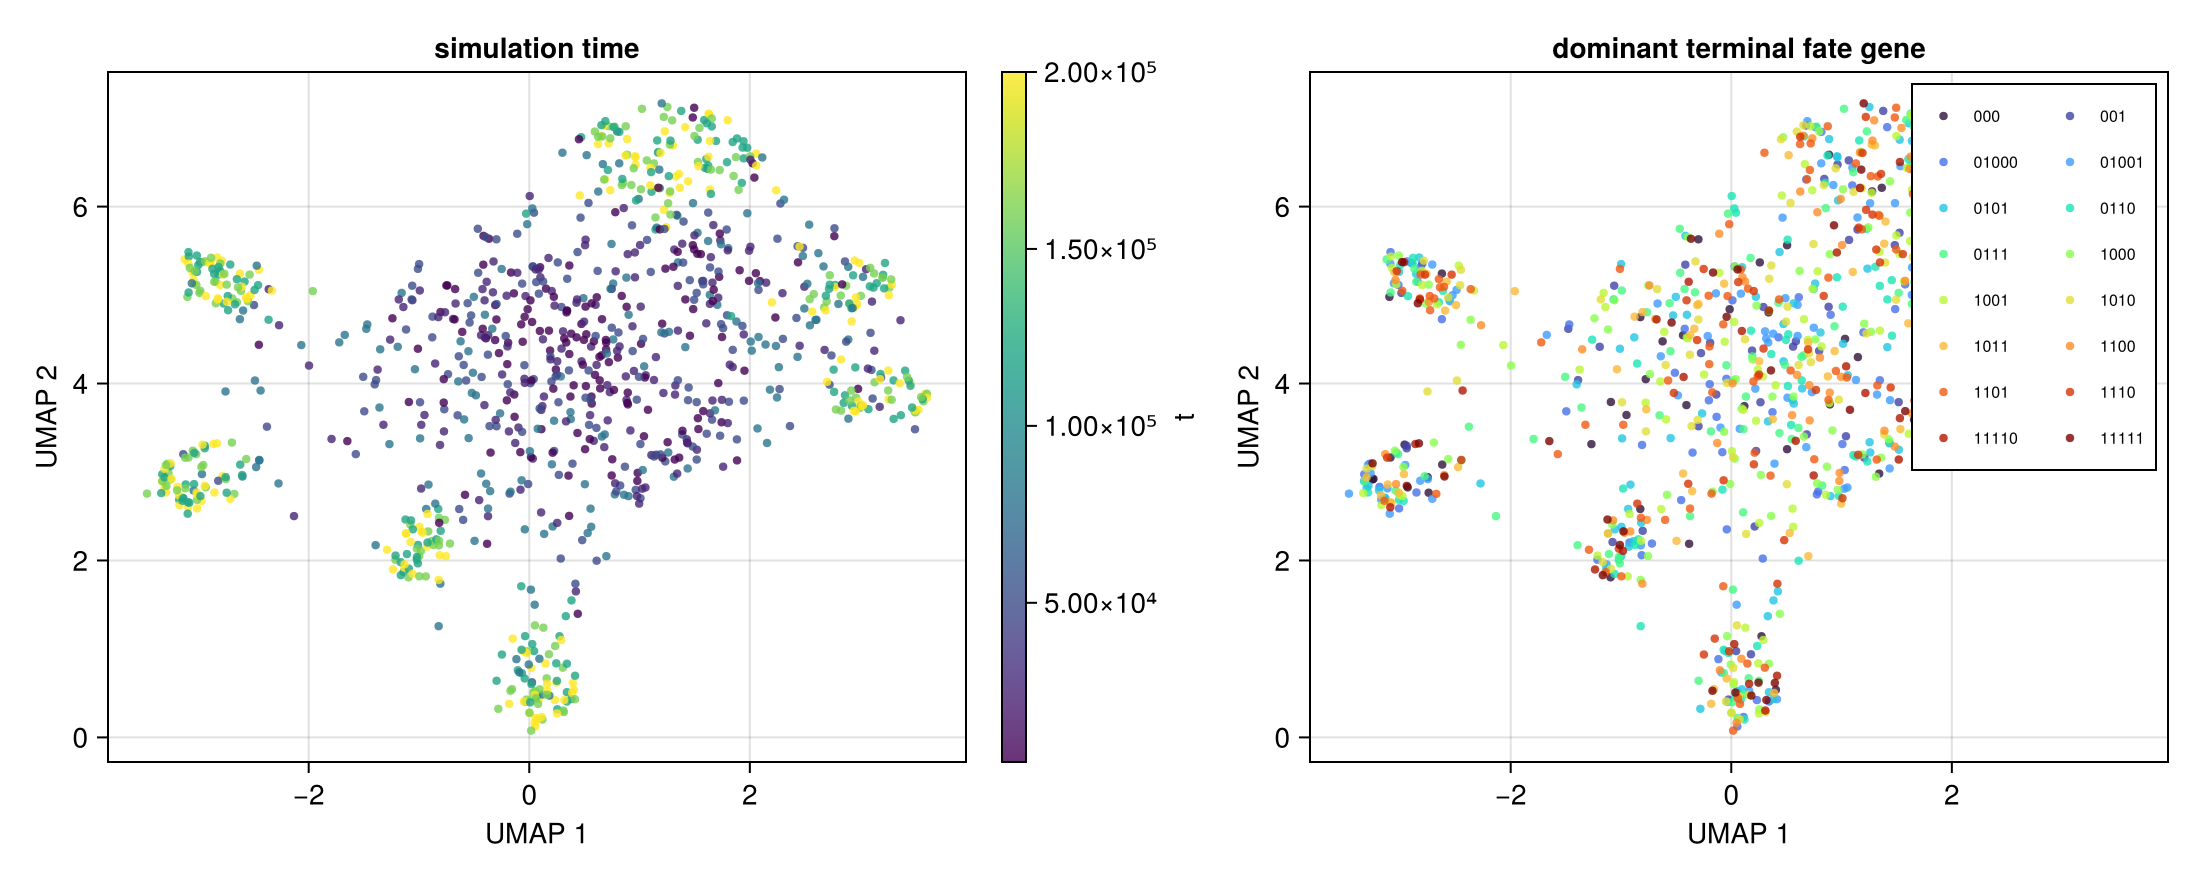

In [37]:

import Pkg
for dep in ["UMAP", "CairoMakie"]
    haskey(Pkg.project().dependencies, dep) || Pkg.add(dep)
end

using UMAP
using CairoMakie

println("Running UMAP on $(size(X_pca, 2))-dim PCA embedding…")
@time result = UMAP.fit(X_pca', 2; n_neighbors=20, min_dist=0.05, n_epochs=500)

umap1 = [e[1] for e in result.embedding]
umap2 = [e[2] for e in result.embedding]

# ---- identify terminal fate genes ----
# Terminal differentiators are named "differentiator" + (possibly empty) binary string.
# The regex r"^(differentiator[01]*)\.mrnas$" matches ONLY those species:
#   - excludes peripheral genes (don't start with "differentiator")
#   - excludes timer genes ("differentiator0_timer.mrnas" has "_timer" not binary digits)
#   - excludes .premrnas (the $ anchor + \.mrnas require the string to end in exactly ".mrnas")
# A gene is a leaf (terminal fate) if neither child "X0" nor "X1" exists.

all_mrna_set = Set(all_genes)
const TERM_RX = r"^(differentiator[01]*)\.mrnas$"

function terminal_gene_name(g::Symbol)
    m = match(TERM_RX, String(g))
    isnothing(m) && return nothing
    gname = m[1]
    # leaf check: no binary children in the mrna set
    Symbol(gname * "0.mrnas") ∈ all_mrna_set && return nothing
    Symbol(gname * "1.mrnas") ∈ all_mrna_set && return nothing
    return gname
end

terminal_mrna = sort!(filter(g -> !isnothing(terminal_gene_name(g)), all_genes))
n_terminal = length(terminal_mrna)
println("Terminal fate species ($n_terminal): $(join(String.(terminal_mrna), ", "))")

# Per-cell: pick the terminal gene with highest normalised expression
term_col_idx = [findfirst(==(g), all_genes) for g in terminal_mrna]
X_fate       = X_norm[:, term_col_idx]

dominant_fate = [terminal_gene_name(terminal_mrna[argmax(X_fate[k, :])]) for k in 1:size(X_fate, 1)]
unique_fates  = sort(unique(dominant_fate))
n_fates       = length(unique_fates)
println("Distinct dominant fates observed: $n_fates / $n_terminal")

# Lineage-ordered colours: alphabetical = L→R tree traversal → siblings share hue
fate_palette = resample_cmap(:turbo, n_fates)
fate_color   = Dict(g => fate_palette[i] for (i, g) in enumerate(unique_fates))

fig = Figure(size = (1100, 440))

ax1 = Axis(fig[1, 1]; title = "simulation time", xlabel = "UMAP 1", ylabel = "UMAP 2")
sc1 = scatter!(ax1, umap1, umap2;
    color = times, colormap = :viridis, markersize = 6, alpha = 0.8)
Colorbar(fig[1, 2], sc1; label = "t")

ax2 = Axis(fig[1, 3]; title = "dominant terminal fate gene", xlabel = "UMAP 1", ylabel = "UMAP 2")
for gname in unique_fates
    mask = dominant_fate .== gname
    short = replace(gname, "differentiator" => "")
    scatter!(ax2, umap1[mask], umap2[mask];
        color = fate_color[gname], label = isempty(short) ? "root" : short,
        markersize = 6, alpha = 0.8)
end
axislegend(ax2; position = :rt, labelsize = 8, nbanks = 2)

fig
